# 🚀 Lab 29: Interactive Crime Map with Folium & GeoJSON

### 📘 Lab Overview
In this lab, you will learn how to build an interactive crime map using **Folium** and **GeoJSON** in Python. You will create a sample crime dataset, generate matching district boundary data in GeoJSON format, visualize crime frequency using **color-coded choropleth layers**, and add **tooltips**, **popups**, **layer controls**, **search**, and **export features**.

This lab has been adapted for **Google Colab**, so everything runs directly inside the notebook. The sample data and GeoJSON files are created programmatically, which means you do not need to upload any external files.

## 🎯 Objectives
By the end of this lab, students will be able to:
* Load and process GeoJSON data containing geographic district boundaries
* Create interactive maps using the Folium library in Python
* Visualize crime frequency data using color-coded choropleth layers
* Implement interactive tooltips to display detailed information on hover
* Add popup windows to display detailed district crime information
* Add layer controls for enhanced user interaction with the map
* Understand the relationship between geographic data and crime statistics
* Export and share interactive HTML maps
* Generate basic statistical insights and supporting charts from crime data

## 🧰 Prerequisites
Before starting this lab, students should have:
* Basic understanding of Python (variables, functions, loops)
* Familiarity with dictionaries and lists
* Basic knowledge of JSON format
* Understanding of geographic concepts (coordinates, districts)
* Some exposure to pandas (helpful but not required)

## ⚙️ Environment Setup
### 💡 ELI10: Setting up our tools
Before we build our map, we need to bring in some special tools. Think of these like a hammer, nails, and paint that help us build and decorate our digital map project.

We will use:
* `folium`: For drawing the interactive maps.
* `json`: For handling geographic data files.
* `pandas` & `numpy`: For organizing our crime numbers.
* `matplotlib`: For making charts.

In [1]:
# Install necessary packages for mapping and data analysis in Colab
%pip install -q folium pandas numpy matplotlib branca

### Subtask 1.1: Import Required Libraries
Now we tell Python to load those tools into its memory so we can use them.

In [2]:
import folium
import json
import pandas as pd
import numpy as np
import random
from datetime import datetime
from folium import plugins
import branca.colormap as cm
import matplotlib.pyplot as plt

# Print versions to ensure environment is correct
print("Folium version:", folium.__version__)
print("Pandas version:", pd.__version__)
print("Setup complete!")

Folium version: 0.20.0
Pandas version: 2.2.2
Setup complete!


## 🚓 Creating Crime Data
### 💡 ELI10: Making up a story with numbers
Since we don't have a real city's crime data right now, we are going to use Python to invent some realistic numbers for 10 different neighborhoods (districts). We'll track things like theft and burglary.

In [3]:
def generate_sample_crime_data(seed=42):
    """Generate realistic sample crime data for mapping."""
    # Set seed for reproducibility so everyone gets the same 'random' data
    random.seed(seed)
    np.random.seed(seed)

    districts = [
        "Downtown", "Riverside", "Northside", "Eastgate", "Westfield",
        "Southpark", "Midtown", "Hillcrest", "Lakewood", "Oakdale"
    ]

    crime_data = []
    for district in districts:
        # Generate random crime counts for various categories
        theft = random.randint(10, 80)
        burglary = random.randint(5, 40)
        assault = random.randint(3, 25)
        vandalism = random.randint(8, 50)
        drug_offense = random.randint(2, 30)

        # Calculate total and ensure it makes sense
        component_sum = theft + burglary + assault + vandalism + drug_offense
        total_crimes = max(random.randint(50, 300), component_sum)

        crime_data.append({
            "district": district,
            "total_crimes": total_crimes,
            "theft": theft,
            "burglary": burglary,
            "assault": assault,
            "vandalism": vandalism,
            "drug_offense": drug_offense
        })

    return pd.DataFrame(crime_data)

# Create our dataframe
crime_df = generate_sample_crime_data()

# Display the first few rows to verify
print("Sample Crime Data:")
display(crime_df.head())
print(f"\nTotal districts: {len(crime_df)}")

Sample Crime Data:


,district,total_crimes,theft,burglary,assault,vandalism,drug_offense
0,Downtown,85,24,6,11,23,9
1,Riverside,127,23,39,5,45,15
2,Northside,204,13,10,9,22,18
3,Eastgate,189,13,40,9,49,24
4,Westfield,257,63,19,17,45,10



Total districts: 10


## 🗺️ Creating GeoJSON Data
### 💡 ELI10: Drawing shapes for our neighborhoods
A map needs to know where the borders of each neighborhood are. We are creating a 'GeoJSON' file, which is just a list of coordinates that tell the computer how to draw a square (district) for each area on our map.

In [4]:
def create_sample_geojson(crime_dataframe, base_lat=40.7128, base_lon=-74.0060):
    """Create sample GeoJSON with district polygons arranged in a grid."""
    districts_geojson = {"type": "FeatureCollection", "features": []}

    for i, district in enumerate(crime_dataframe["district"]):
        # Arrange districts in a simple grid pattern for visualization
        row, col = i // 4, i % 4
        lat_offset, lon_offset = row * 0.02, col * 0.02

        # Define the corners of our district square
        coordinates = [[
            [base_lon + lon_offset,         base_lat + lat_offset],
            [base_lon + lon_offset + 0.015, base_lat + lat_offset],
            [base_lon + lon_offset + 0.015, base_lat + lat_offset + 0.015],
            [base_lon + lon_offset,         base_lat + lat_offset + 0.015],
            [base_lon + lon_offset,         base_lat + lat_offset]
        ]]

        feature = {
            "type": "Feature",
            "properties": {"name": district, "district_id": i + 1},
            "geometry": {"type": "Polygon", "coordinates": coordinates}
        }
        districts_geojson["features"].append(feature)

    return districts_geojson

# Generate and save the GeoJSON file
districts_geojson = create_sample_geojson(crime_df)
with open("districts.geojson", "w") as f:
    json.dump(districts_geojson, f, indent=2)

print("GeoJSON created and saved to 'districts.geojson'")

GeoJSON created and saved to 'districts.geojson'


### Subtask 1.4: Enrich GeoJSON with Crime Statistics
**Why do we do this?** For tooltips and search to work instantly when you hover over a map, the geographic data (the shape) needs to 'know' its own crime stats. We merge our table of numbers into the GeoJSON properties.

In [5]:
def enrich_geojson_with_crime_data(geojson_data, crime_dataframe):
    """Attach crime statistics to each GeoJSON feature's properties."""
    # Create a lookup dictionary from the dataframe
    crime_lookup = crime_dataframe.set_index("district").to_dict(orient="index")

    # Deep copy the geojson to avoid modifying the original
    enriched = json.loads(json.dumps(geojson_data))

    for feature in enriched["features"]:
        district_name = feature["properties"]["name"]
        if district_name in crime_lookup:
            # Add the crime stats into the 'properties' section of each feature
            feature["properties"].update(crime_lookup[district_name])

    return enriched

enriched_geojson = enrich_geojson_with_crime_data(districts_geojson, crime_df)
print("GeoJSON successfully enriched with crime properties.")

GeoJSON successfully enriched with crime properties.


## 📍 Building the Base Map
### 💡 ELI10: Opening the paper map
Before we draw districts, we need a blank map of the world. We'll center it on New York City coordinates for this lab.

In [6]:
def create_base_map():
    """Create the base Folium map centered on NYC coordinates."""
    m = folium.Map(
        location=[40.7128, -74.0060],
        zoom_start=12,
        tiles="OpenStreetMap"
    )
    return m

base_map = create_base_map()

# Add boundaries to see the districts on the blank map
folium.GeoJson(
    enriched_geojson,
    name="District Boundaries",
    style_function=lambda feature: {
        "fillColor": "lightblue", "color": "black", "weight": 2, "fillOpacity": 0.3
    },
    tooltip=folium.features.GeoJsonTooltip(fields=["name"], aliases=["District:"])
).add_to(base_map)

display(base_map)

## 🌈 Choropleth Crime Layers
### 💡 ELI10: Coloring by numbers
A 'Choropleth' is just a fancy word for a map that uses colors to show values. Dark red might mean 'more crime,' while yellow means 'less crime.' This helps us see patterns instantly.

In [7]:
def create_crime_choropleth_map():
    """Create a choropleth map showing total crime frequency."""
    crime_map = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

    # Create the choropleth layer
    choropleth = folium.Choropleth(
        geo_data=enriched_geojson, # The shapes
        name="Total Crime Frequency",
        data=crime_df, # The numbers
        columns=["district", "total_crimes"],
        key_on="feature.properties.name", # How to link shapes to numbers
        fill_color="YlOrRd", # Yellow to Orange to Red scale
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name="Total Crimes per District",
        bins=5
    ).add_to(crime_map)

    # Add a simple tooltip to the choropleth
    choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(fields=["name", "total_crimes"], aliases=["District:", "Total Crimes:"])
    )

    return crime_map

choropleth_map = create_crime_choropleth_map()
display(choropleth_map)

## 💬 Tooltips and Popups
### 💡 ELI10: Hover and Click
We want the map to talk to us! When we hover (tooltip), it should show quick stats. When we click (popup), it should show a detailed report card for that district.

In [8]:
def add_crime_popups(map_object, geojson_data):
    """Add markers with HTML popup windows for each district."""
    marker_group = folium.FeatureGroup(name="Detailed Crime Stats")

    for feature in geojson_data["features"]:
        p = feature["properties"]
        # Build a nice HTML table for the popup
        popup_html = f"""
        <div style='font-family: Arial; width: 200px;'>
            <h4 style='color: #2E86AB;'>{p['name']} District</h4>
            <hr>
            <b>Total: {p['total_crimes']}</b><br>
            Theft: {p['theft']}<br>
            Burglary: {p['burglary']}<br>
            Assault: {p['assault']}<br>
            Vandalism: {p['vandalism']}<br>
            Drugs: {p['drug_offense']}
        </div>
        """
        # Calculate the center of the square to place the marker
        coords = feature["geometry"]["coordinates"][0]
        center_lat = sum(c[1] for c in coords) / len(coords)
        center_lon = sum(c[0] for c in coords) / len(coords)

        folium.Marker(
            location=[center_lat, center_lon],
            popup=folium.Popup(popup_html, max_width=300),
            icon=folium.Icon(color="red", icon="info-sign"),
            tooltip=f"Click for {p['name']} details"
        ).add_to(marker_group)

    marker_group.add_to(map_object)
    return map_object

## 🎛 Layer Controls and Search
### 💡 ELI10: The Dashboard
Now we combine everything. We'll add a 'Layer Control' (a menu to turn layers on/off) and a 'Search' bar so you can find a district by name.

In [9]:
def create_final_crime_map():
    """Assembles the final interactive map with all features."""
    final_map = create_base_map()

    # Create a searchable layer for the search tool
    search_layer = folium.GeoJson(
        enriched_geojson,
        name="Interactive Search Layer",
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 1},
        tooltip=folium.features.GeoJsonTooltip(
            fields=["name", "total_crimes", "theft", "burglary", "assault", "vandalism", "drug_offense"],
            aliases=["District:", "Total:", "Theft:", "Burglary:", "Assault:", "Vandalism:", "Drugs:"]
        )
    ).add_to(final_map)

    # Add the click-based popups
    add_crime_popups(final_map, enriched_geojson)

    # Add interactive plugins
    folium.LayerControl().add_to(final_map)
    plugins.Fullscreen().add_to(final_map)
    plugins.Search(layer=search_layer, search_label="name", placeholder="Find a district...", collapsed=False).add_to(final_map)
    plugins.MiniMap().add_to(final_map)

    return final_map

final_crime_map = create_final_crime_map()
display(final_crime_map)

## 📊 Crime Analysis
### 💡 ELI10: Looking for clues
Maps are great, but sometimes we need charts to see which crime is most common or which neighborhood is the safest at a glance.

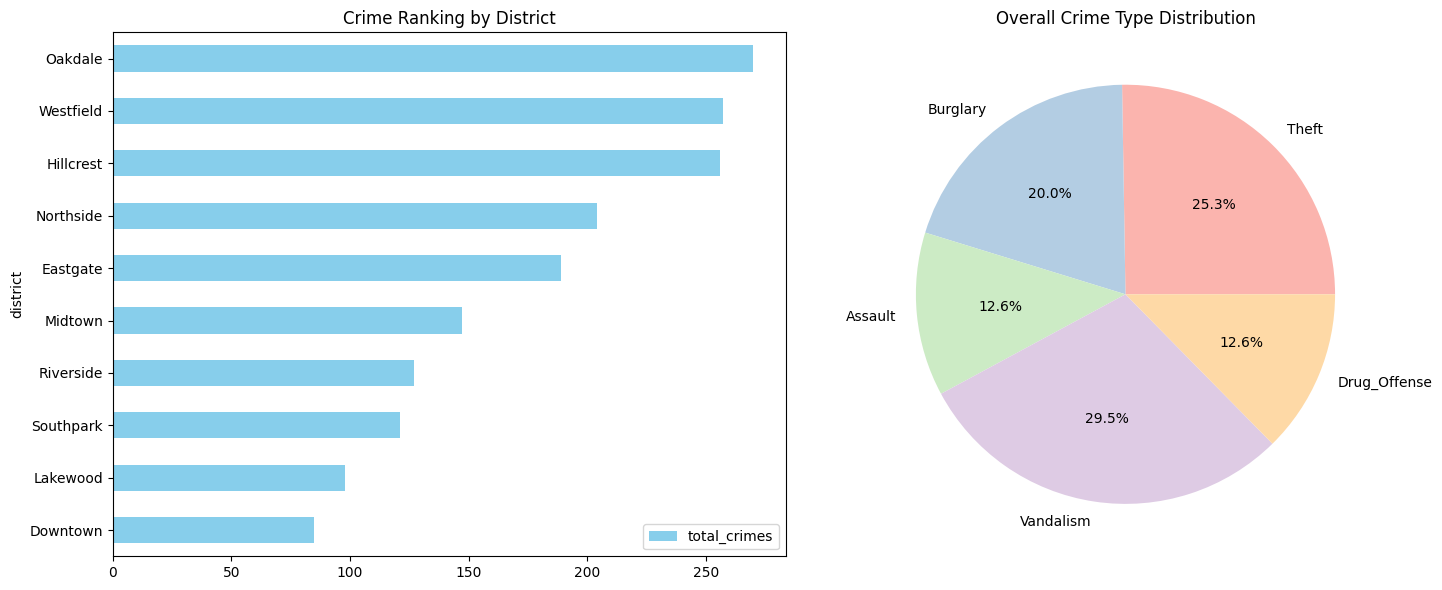

<Figure size 640x480 with 0 Axes>

In [10]:
def create_crime_charts(df):
    """Create supplementary charts for crime data analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Chart 1: Rankings
    df.sort_values("total_crimes").plot(kind='barh', x='district', y='total_crimes', ax=axes[0], color='skyblue')
    axes[0].set_title("Crime Ranking by District")

    # Chart 2: Type Breakdown
    types = ["theft", "burglary", "assault", "vandalism", "drug_offense"]
    totals = [df[t].sum() for t in types]
    axes[1].pie(totals, labels=[t.title() for t in types], autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
    axes[1].set_title("Overall Crime Type Distribution")

    plt.tight_layout()
    plt.show()
    plt.savefig("crime_analysis_charts.png")

create_crime_charts(crime_df)

## 💾 Saving and Exporting the Map
### 💡 ELI10: Taking it with you
You can save this map as a single HTML file and send it to anyone. They don't even need Python to see it—just a web browser!

In [11]:
from google.colab import files

# Save the map to a file
final_crime_map.save("interactive_crime_map.html")

print("Map saved as 'interactive_crime_map.html'.")
# Uncomment the next line to download it automatically to your computer
# files.download("interactive_crime_map.html")

Map saved as 'interactive_crime_map.html'.


# ✅ Verification
Check the following:
1. Did the `crime_df` display correctly?
2. Does the map show 10 square districts?
3. Do the colors change when you toggle layers?
4. Does the search bar find "Downtown"?
5. Can you click the red markers for details?

# 🛠 Troubleshooting
* **Map is blank?** Ensure the last line of the cell is the map object name (e.g., `final_crime_map`).
* **Search not working?** The search tool must be linked to a GeoJson layer where the `properties` contain the name field.
* **No colors?** Check that `key_on` in the Choropleth settings matches the path to the name in your GeoJSON.

# 🏁 Conclusion
You have successfully built a professional, interactive crime dashboard. You've learned how to link geographic shapes (GeoJSON) with statistical data (Pandas) and create a user-friendly interface using Folium plugins. This is a core skill for anyone working in urban planning, public safety, or data journalism.